# Violin plot of ΔE (Nature-style, Arial, PDF export)

This notebook reads `energy_min_comparison.csv`, extracts `ΔE = min(random best-of-K) − proxy_best`,
and produces a publication-style violin plot.

- Font: Arial
- Nature-style color (single-color fill + black outline)
- Exports a high-quality vector PDF


[OK] Saved: energy_min_violin_deltaE_nature.pdf


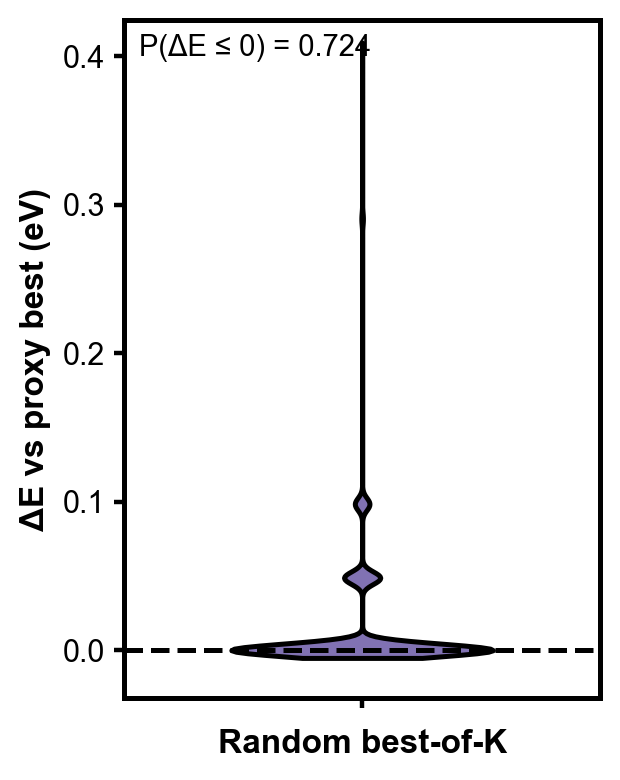

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# User settings
# ==============================
csv_path = 'energy_min_comparison.csv'
out_pdf  = 'energy_min_violin_deltaE_nature.pdf'

# Nature-style single color (pick one that is distinct & publication-friendly)
# (purple from a common "Nature-like" palette)
fill_color = '#8172B3'

# ==============================
# Matplotlib global style (Arial + black axes)
# ==============================
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],  # fallback if Arial missing
    'pdf.fonttype': 42,   # embed TrueType
    'ps.fonttype': 42,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
})

# ==============================
# Load CSV and compute ΔE robustly
# ==============================
df = pd.read_csv(csv_path)

if 'delta_random_min_minus_proxybest_eV' in df.columns:
    deltaE = df['delta_random_min_minus_proxybest_eV'].to_numpy(dtype=float)
else:
    # fallback for older schemas
    proxy_cols = [c for c in df.columns if re.match(r'proxy_.*_eV$', c)]
    if 'top8_best_energy_eV' in df.columns:
        proxy_best = float(df['top8_best_energy_eV'].iloc[0])
    elif len(proxy_cols) >= 1:
        proxy_best = float(df[proxy_cols[0]].iloc[0])
    else:
        raise KeyError('Cannot find proxy baseline column. Expected delta_random_min_minus_proxybest_eV or proxy_*_eV.')

    min_cols = [c for c in df.columns if c.startswith('min_energy_random') and c.endswith('_eV')]
    if len(min_cols) == 0:
        raise KeyError("Cannot find random min column. Expected 'min_energy_random..._eV'.")
    random_min = df[min_cols[0]].to_numpy(dtype=float)
    deltaE = random_min - proxy_best

deltaE = deltaE[np.isfinite(deltaE)]
if deltaE.size == 0:
    raise ValueError('No finite ΔE values found. Check your CSV.')

# ==============================
# Plot
# ==============================
fig, ax = plt.subplots(figsize=(3.2, 4.0), dpi=200)

# Slim, tapered violin (KDE boundary handling)
plot_df = pd.DataFrame({'ΔE': deltaE})
sns.violinplot(
    data=plot_df,
    y='ΔE',
    inner=None,
    cut=1.2,
    bw_adjust=0.55,
    gridsize=400,
    width=0.55,
    linewidth=1.8,
    ax=ax,
)

# Recolor violin body (seaborn sets artists; recolor to a Nature-like single fill)
for coll in ax.collections:
    try:
        coll.set_facecolor(fill_color)
        coll.set_edgecolor('black')
        coll.set_linewidth(1.8)
        coll.set_alpha(1.0)
    except Exception:
        pass

# Baseline at 0
ax.axhline(0.0, ls='--', lw=1.8, color='black')

# Labels
ax.set_xlabel('Random best-of-K', fontsize=12, fontweight='bold')
ax.set_ylabel('ΔE vs proxy best (eV)', fontsize=12, fontweight='bold')

# Show a small y<0 region so the violin visually tapers rather than truncates at 0
ymax = float(np.nanmax(deltaE))
ymin = float(np.nanmin(deltaE))
pad_neg = max(0.02, 0.08 * (ymax - ymin + 1e-12))
ax.set_ylim(-pad_neg, ymax + 0.05 * (ymax - ymin + 1e-12))

# Axis styling
ax.tick_params(axis='both', which='both', labelsize=11, width=1.6, colors='black')
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    spine.set_color('black')

# Optional: probability annotation
p_le0 = float(np.mean(deltaE <= 0.0))
ax.text(0.03, 0.98, f"P(ΔE ≤ 0) = {p_le0:.3g}", transform=ax.transAxes,
        ha='left', va='top', fontsize=10.5, color='black')

plt.tight_layout()

# Export vector PDF (high quality). dpi is ignored for vector, but kept for safety.
fig.savefig(out_pdf, bbox_inches='tight')
print(f"[OK] Saved: {out_pdf}")

plt.show()
